# bt_02：用 vectorbt 批量扫描均线参数

本 notebook 的目标不是寻找“最优参数”，而是学习如何用 `vectorbt` 一次性回测多组均线参数，并检查策略是否对参数过度敏感。

核心检查：

1. 使用同一份价格数据；
2. 对多组均线窗口批量生成信号；
3. 信号滞后一日，避免使用当天收盘价后又当天成交；
4. 加入手续费；
5. 对比总收益、最大回撤、夏普、交易次数；
6. 观察表现是否集中在孤立参数上。

In [4]:
import numpy as np
import pandas as pd
import vectorbt as vbt

print("vectorbt", vbt.__version__)
print("pandas", pd.__version__)
print("numpy", np.__version__)

vectorbt 0.28.2
pandas 3.0.3
numpy 2.4.6


## 1. 构造一组可复现的示例价格

这里先用模拟价格学习流程。以后替换成 ETF 的真实收盘价时，只需要保证 `close` 是按日期升序排列的 `pd.Series`。

In [5]:
# 固定随机种子，让每次运行都生成同一组随机数，方便复现实验结果
np.random.seed(42)

# 生成 320 个交易日日期索引；bdate_range 默认跳过周末
dates = pd.bdate_range("2023-01-02", periods=320)

# 构造长期趋势：从 0 平滑上升到 0.35，表示价格整体向上漂移
trend = np.linspace(0, 0.35, len(dates))

# 构造周期波动：sin 曲线模拟价格的阶段性起伏，0.08 控制波动幅度
cycle = 0.08 * np.sin(np.linspace(0, 8 * np.pi, len(dates)))

# 构造随机噪声：每天一个小随机冲击，再累加成类似随机游走的扰动
noise = np.random.normal(0, 0.012, len(dates)).cumsum()

# 合成收盘价：趋势 + 周期 + 噪声 先作为对数价格变化，再用 exp 转成始终为正的价格
close = pd.Series(100 * np.exp(trend + cycle + noise), index=dates, name="close")

# 查看前 5 行，确认日期索引和价格序列是否符合预期
close.head()

2023-01-02    100.597837
2023-01-03    101.176359
2023-01-04    102.718462
2023-01-05    105.377045
2023-01-06    105.836490
Freq: B, Name: close, dtype: float64

## 2. 批量计算均线

`window` 传入一个列表时，`vectorbt` 会一次性计算多组均线。每一列对应一个均线窗口。

In [6]:
windows = np.array([5, 10, 20, 30, 60, 90, 120, 200])

# 用 vectorbt 的 MA 指标一次性计算多组移动平均线；每个 window 对应一条均线
ma = vbt.MA.run(close, window=windows)

# ma 是 vectorbt 的指标对象，ma.ma 才是真正的均线数值表
ma_values = ma.ma
ma_values.tail()

ma_window,5,10,20,30,60,90,120,200
2024-03-18,139.282888,135.156853,130.150164,127.977415,131.636201,131.132054,127.415867,119.243195
2024-03-19,141.458636,136.698803,131.284267,128.646412,131.634974,131.412417,127.661351,119.457317
2024-03-20,143.297106,138.325290,132.422605,129.320576,131.657075,131.709796,127.914244,119.683717
2024-03-21,145.014578,139.966165,133.581086,130.051942,131.689133,132.030423,128.185173,119.914026
2024-03-22,146.272102,141.654834,134.730399,130.858128,131.709366,132.342798,128.481285,120.146696


## 3. 生成买入/卖出信号，并滞后一日

规则：

- 原始买入：收盘价上穿均线；
- 原始卖出：收盘价下穿均线；
- 实际执行信号：统一 `shift(1)`，表示今天收盘后看到的信号，下一交易日才执行。

这一步是为了避免 look-ahead bias。

In [ ]:
raw_entries = close.vbt.crossed_above(ma_values)
raw_exits = close.vbt.crossed_below(ma_values)

entries = raw_entries.shift(1).fillna(False).astype(bool)
exits = raw_exits.shift(1).fillna(False).astype(bool)
# concat拼接series来的
signal_preview = pd.concat(
    {
        "close": close,
        "ma_20": ma_values[20],
        "raw_entry_20": raw_entries[20],
        "entry_20_after_shift": entries[20],
        "raw_exit_20": raw_exits[20],
        "exit_20_after_shift": exits[20],
    },
    axis=1,
)
signal_preview[signal_preview[["raw_entry_20", "entry_20_after_shift", "raw_exit_20", "exit_20_after_shift"]].any(axis=1)].head(10)

,close,ma_20,raw_entry_20,entry_20_after_shift,raw_exit_20,exit_20_after_shift
2023-04-03,88.423798,87.451417,True,False,False,False
2023-04-04,88.686193,87.440427,False,True,False,False
2023-05-24,104.063129,104.551840,False,False,True,False
2023-05-25,103.036440,104.675557,False,False,False,True
2023-05-30,105.313238,105.090820,True,False,False,False
2023-05-31,105.310089,105.192751,False,True,False,False
2023-06-02,104.965400,105.320329,False,False,True,False
2023-06-05,102.237877,105.170575,False,False,False,True
2023-07-24,95.982314,95.550192,True,False,False,False
2023-07-25,94.941324,95.268371,False,True,True,False


## 4. 用 `Portfolio.from_signals` 批量回测

这里每个均线窗口会形成一列策略。`fees=0.001` 表示单边手续费 0.1%。

In [12]:
portfolio = vbt.Portfolio.from_signals(
    close=close,
    entries=entries,
    exits=exits,
    init_cash=100_000,
    fees=0.001,
    freq="1D",
)

portfolio.wrapper.columns

Index([5, 10, 20, 30, 60, 90, 120, 200], dtype='int64', name='ma_window')

## 5. 汇总参数扫描结果

重点看参数区域是否整体稳定，而不是只盯收益最高的单个参数。

In [10]:
scan_result = pd.DataFrame(
    {
        "total_return": portfolio.total_return(),
        "annualized_return": portfolio.annualized_return(),
        "max_drawdown": portfolio.max_drawdown(),
        "sharpe_ratio": portfolio.sharpe_ratio(),
        "total_trades": portfolio.trades.count(),
        "final_value": portfolio.final_value(),
    }
)

scan_result.index.name = "ma_window"
scan_result = scan_result.sort_index()
scan_result

,total_return,annualized_return,max_drawdown,sharpe_ratio,total_trades,final_value
ma_window,,,,,,
5,0.628073,0.743575,-0.107449,3.348721,33,162807.306830
10,0.889439,1.066294,-0.074693,4.415309,17,188943.878857
20,0.905023,1.085745,-0.081550,4.413787,7,190502.318614
30,0.809085,0.966365,-0.081273,4.011672,5,180908.511457
60,0.338421,0.394424,-0.128423,1.949696,7,133842.066997
90,0.424057,0.496639,-0.150219,2.396607,3,142405.673507
120,0.480645,0.564662,-0.163587,2.610440,3,148064.514307
200,0.000000,0.000000,0.000000,inf,0,100000.000000


## 6. 找出收益最高参数，但不把它当结论

收益最高的参数只能作为观察对象，不能直接当成未来实盘参数。更重要的是看它附近的参数是否也表现接近。

In [11]:
best_window = scan_result["total_return"].idxmax()
neighbor_windows = [window for window in windows if abs(window - best_window) <= 30]

print(f"收益最高的均线窗口: {best_window}")
print("附近窗口:", neighbor_windows)

display(scan_result.loc[neighbor_windows].sort_values("total_return", ascending=False))

收益最高的均线窗口: 20
附近窗口: [np.int64(5), np.int64(10), np.int64(20), np.int64(30)]


,total_return,annualized_return,max_drawdown,sharpe_ratio,total_trades,final_value
ma_window,,,,,,
20,0.905023,1.085745,-0.081550,4.413787,7,190502.318614
10,0.889439,1.066294,-0.074693,4.415309,17,188943.878857
30,0.809085,0.966365,-0.081273,4.011672,5,180908.511457
5,0.628073,0.743575,-0.107449,3.348721,33,162807.306830


## 7. 画出不同参数的资金曲线

资金曲线用于观察：

- 哪些参数回撤更深；
- 哪些参数只在局部阶段有效；
- 参数变化后曲线形态是否剧烈改变。

<Axes: title={'center': 'MA parameter scan - portfolio value'}>

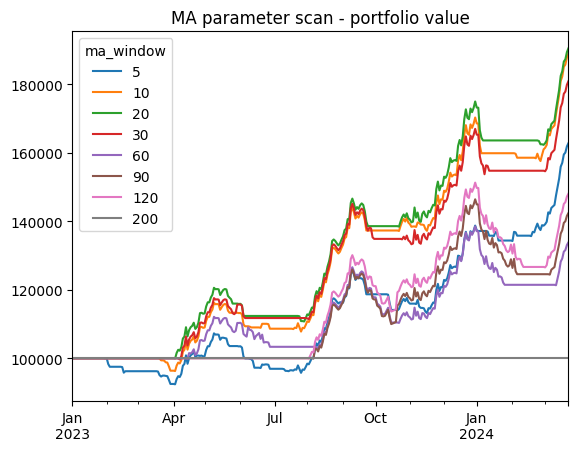

In [ ]:
# value() 表示每一天的账户总值
portfolio.value().plot(title="MA parameter scan - portfolio value")

## 8. 复盘检查清单

完成参数扫描后，至少回答这些问题：

1. 是否所有信号都做了 `shift(1)`？
2. 是否加入了手续费？
3. 收益最高参数是否是孤立点？
4. 相邻参数表现是否接近？
5. 最大回撤是否可接受？
6. 交易次数是否过高？
7. 换成真实 ETF 数据后，结论是否仍然成立？

记住：参数扫描不是为了找冠军，而是为了检查策略是否稳健。